# Acceptance Rate Analysis — AIDev Dataset (Direct)

This notebook computes acceptance/rejection rates for AI-agent fix PRs **directly from the AIDev dataset**,
ensuring results are consistent with the dataset used in the paper.

**Agents studied:** Copilot, Devin, Cursor, Claude Code (Codex excluded per paper methodology).

**Produces:**
- `results/aidev_report_figures/` — PNG figures
- `results/aidev_report.txt` — text summary

In [1]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [2]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [3]:
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "aidev_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "aidev_report.txt"

## Load AIDev Dataset Directly

In [4]:
AIDEV_BASE = "hf://datasets/hao-li/AIDev"

AGENTS_STUDIED = ["Copilot", "Devin", "Cursor", "Claude_Code"]

print("Loading AIDev repository table ...")
repo_df = pd.read_parquet(f"{AIDEV_BASE}/repository.parquet")
print(f"  Repos: {len(repo_df):,}  (all have >100 stars)")

print("\nLoading AIDev all_pull_request table (4 agents) ...")
all_prs_raw = pd.read_parquet(
    f"{AIDEV_BASE}/all_pull_request.parquet",
    filters=[("agent", "in", AGENTS_STUDIED)],
)
print(f"  Agent PRs loaded: {len(all_prs_raw):,}")
print(f"  Agent distribution:")
for agent, cnt in all_prs_raw["agent"].value_counts().items():
    print(f"    {agent:20s} {cnt:>8,}")
print(f"  State distribution:")
print(f"    closed: {(all_prs_raw['state'] == 'closed').sum():,}")
print(f"    open:   {(all_prs_raw['state'] == 'open').sum():,}")

Loading AIDev repository table ...


c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Repos: 2,807  (all have >100 stars)

Loading AIDev all_pull_request table (4 agents) ...
  Agent PRs loaded: 118,269
  Agent distribution:
    Copilot                50,447
    Cursor                 32,941
    Devin                  29,744
    Claude_Code             5,137
  State distribution:
    closed: 98,895
    open:   19,374


## Fix PR Classification

In [5]:
FIX_PATTERN = re.compile(
    r"(^fix(\([^)]*\))?!?[\s:!/])"       # conventional: fix:, fix(scope):, fix!:
    r"|(\bfix(es|ed|ing)?\b)"             # natural language: fix, fixes, fixed, fixing
    r"|(\bbug\s*fix\b)"                   # "bugfix" or "bug fix"
    r"|(\bhotfix\b)"                      # hotfix
    r"|(\bbug\b)"                         # bug
    r"|(\bpatch\b)"                       # patch
    r"|(\bresolv(e[ds]?|ing)\b)"          # resolve, resolved, resolves, resolving
    r"|(\berror\b)"                       # error
    r"|(\bcrash(es|ed|ing)?\b)"           # crash, crashes, crashed, crashing
    r"|(\bdefect\b)"                      # defect
    r"|(\bregression\b)"                  # regression
    r"|(\bbroken\b)",                     # broken
    flags=re.IGNORECASE,
)


def classify_title(title: str) -> str:
    if not title or not isinstance(title, str):
        return "other"
    return "fix" if FIX_PATTERN.search(title) else "other"


all_prs_raw["type"] = all_prs_raw["title"].apply(classify_title)

fix_count = (all_prs_raw["type"] == "fix").sum()
other_count = len(all_prs_raw) - fix_count
print(f"Fix PRs:   {fix_count:,}")
print(f"Other PRs: {other_count:,}")
print(f"Fix ratio: {fix_count / len(all_prs_raw) * 100:.1f}%")

Fix PRs:   27,447
Other PRs: 90,822
Fix ratio: 23.2%


## Filter: Closed Fix PRs Only

Following the paper methodology: exclude open PRs, keep only closed (merged + closed-unmerged).

In [6]:
fix_prs = all_prs_raw[all_prs_raw["type"] == "fix"].copy()
print(f"All fix PRs (4 agents): {len(fix_prs):,}")
print(f"  State: closed={( fix_prs['state'] == 'closed').sum():,}, open={(fix_prs['state'] == 'open').sum():,}")

# Exclude open PRs
fix_prs = fix_prs[fix_prs["state"] == "closed"].copy()
fix_prs["is_merged"] = fix_prs["merged_at"].notna()

# Add repo_name from repo table
repo_name_map = dict(zip(repo_df["id"], repo_df["full_name"]))
fix_prs["repo_name"] = fix_prs["repo_id"].map(repo_name_map)

print(f"\nClosed fix PRs (4 agents): {len(fix_prs):,}")
print(f"  Merged:   {fix_prs['is_merged'].sum():,}")
print(f"  Rejected: {(~fix_prs['is_merged']).sum():,}")
print(f"  Repos:    {fix_prs['repo_name'].nunique():,}")

All fix PRs (4 agents): 27,447
  State: closed=23,845, open=3,602

Closed fix PRs (4 agents): 23,845
  Merged:   18,659
  Rejected: 5,186
  Repos:    739


In [7]:
display(fix_prs.sample(10))

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,type,is_merged,repo_name
106776,3150882241,36,Fix Property message serialization to match Ko...,# Fix Property Message Serialization to Match ...,Devin,158243242,devin-ai-integration[bot],closed,2025-06-16T18:21:01Z,2025-06-16T18:23:48Z,2025-06-16T18:23:48Z,1.001414e+09,https://api.github.com/repos/atsushieno/midicci,https://github.com/atsushieno/midicci/pull/36,fix,True,NaN
80105,3219467135,2,"Fix audio recording, processing, and state man...",None,Cursor,110347609,wassemashaik,closed,2025-07-10T13:55:01Z,2025-07-10T13:55:29Z,2025-07-10T13:55:29Z,1.017229e+09,https://api.github.com/repos/wassemashaik/ai-v...,https://github.com/wassemashaik/ai-voice-assis...,fix,True,NaN
35181,3207904295,351,Fix UI elements not refreshing when filter pan...,## Problem\n\nWhen filter panel filters are re...,Copilot,198982749,Copilot,closed,2025-07-07T07:43:03Z,2025-07-07T09:48:39Z,None,3.832708e+08,https://api.github.com/repos/insightsengineeri...,https://github.com/insightsengineering/teal.go...,fix,False,NaN
96548,2793436200,17,Improve GitLab runner scripts with enhanced lo...,# Improve GitLab Runner Scripts with Enhanced ...,Devin,158243242,devin-ai-integration[bot],closed,2025-01-16T18:13:50Z,2025-01-16T18:14:38Z,2025-01-16T18:14:38Z,9.155987e+08,https://api.github.com/repos/raimonvibe/Raimon,https://github.com/raimonvibe/Raimon/pull/17,fix,True,NaN
14077,3132269649,10,Fix bulk analysis timeout by implementing para...,The bulk analysis feature was failing with `Er...,Copilot,198982749,Copilot,closed,2025-06-10T06:12:23Z,2025-06-10T06:39:51Z,2025-06-10T06:39:51Z,9.636213e+08,https://api.github.com/repos/rodneyg/reddit-an...,https://github.com/rodneyg/reddit-analytics/pu...,fix,True,NaN
19383,3266498193,10,Fix Garmin manifest.xml ID length and XML sche...,This PR addresses two critical validation issu...,Copilot,198982749,Copilot,closed,2025-07-27T03:18:23Z,2025-07-27T03:26:29Z,2025-07-27T03:26:29Z,1.009270e+09,https://api.github.com/repos/alexanderkyte/eve...,https://github.com/alexanderkyte/eversense-com...,fix,True,NaN
25598,3196665011,62,Fix all SEO indexing issues: consolidate dupli...,"## 🎯 Operation ""Index Like A Pro"" - Complete S...",Copilot,198982749,Copilot,closed,2025-07-02T17:28:38Z,2025-07-02T17:36:55Z,2025-07-02T17:36:55Z,1.007052e+09,https://api.github.com/repos/jjmandog/jaysmobi...,https://github.com/jjmandog/jaysmobilewash/pul...,fix,True,NaN
14814,3144059074,6,Fix workflow failures by removing non-existent...,The GitHub Actions workflow was failing becaus...,Copilot,198982749,Copilot,closed,2025-06-13T16:09:33Z,2025-06-13T16:31:12Z,2025-06-13T16:31:11Z,4.861182e+08,https://api.github.com/repos/helium729/vigna,https://github.com/helium729/vigna/pull/6,fix,True,NaN
29071,3211231537,7,Fix DiscordAPIError[50001]: Missing Access err...,## Problem\n\nThe bot was encountering `Discor...,Copilot,198982749,Copilot,closed,2025-07-08T06:36:05Z,2025-07-08T06:37:10Z,None,6.687962e+08,https://api.github.com/repos/muralianand12345/...,https://github.com/muralianand12345/Pepper-Bot...,fix,False,NaN
4932,3206431655,30,fix: タグキャッシュ無効化問題を修正しJotai更新ロジックを共通化,## Summary\n- タグのキャッシュ無効化問題を修正し、新規タグが登録・編集画面で正...,Claude_Code,144312244,gs223gs,closed,2025-07-06T11:39:36Z,2025-07-06T11:41:31Z,None,1.010951e+09,https://api.github.com/repos/gs223gs/ReMeet,https://github.com/gs223gs/ReMeet/pull/30,fix,False,NaN


## Helper Functions

In [8]:
report_lines: list[str] = []


def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")


def out(line: str = ""):
    report_lines.append(line)
    print(line)


def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = int(df["merged_at"].notna().sum())
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

## Dataset Overview

In [9]:
section("Dataset Overview (AIDev — Closed Fix PRs)")
out(f"Data source        : AIDev dataset (hao-li/AIDev on Hugging Face)")
out(f"Date range         : {fix_prs['created_at'].min()[:10]} to {fix_prs['created_at'].max()[:10]}")
out(f"Agents studied     : {', '.join(AGENTS_STUDIED)}")
out(f"Total closed fix PRs : {len(fix_prs):,}")
out(f"Repositories       : {fix_prs['repo_name'].nunique():,}")

out("\nPer-agent fix PR counts:")
for agent, cnt in fix_prs["agent"].value_counts().items():
    out(f"  {agent:20s} {cnt:>8,}")


  Dataset Overview (AIDev — Closed Fix PRs)
Data source        : AIDev dataset (hao-li/AIDev on Hugging Face)
Date range         : 2024-12-24 to 2025-07-30
Agents studied     : Copilot, Devin, Cursor, Claude_Code
Total closed fix PRs : 23,845
Repositories       : 739

Per-agent fix PR counts:
  Copilot                10,723
  Devin                   6,882
  Cursor                  5,022
  Claude_Code             1,218


## Acceptance / Rejection Rates

**Core metric:** A closed PR is *accepted* if `merged_at` is not null, otherwise *rejected*.

In [10]:
section("Acceptance / Rejection Rates")

# Overall
total_merged, total_count, total_rate = merge_rate(fix_prs)
total_rejected = total_count - total_merged
rejection_rate = 100 - total_rate

out(f"Overall (4 agents combined):")
out(f"  Accepted (merged)      : {total_merged:,} / {total_count:,} = {total_rate:.2f}%")
out(f"  Rejected (closed only) : {total_rejected:,} / {total_count:,} = {rejection_rate:.2f}%")

# Per agent
out(f"\nPer-agent breakdown:")
agent_stats = []
for agent_name in sorted(fix_prs["agent"].unique()):
    grp = fix_prs[fix_prs["agent"] == agent_name]
    m, t, r = merge_rate(grp)
    rej = t - m
    rej_r = 100 - r
    agent_stats.append({
        "Agent": agent_name,
        "#Accepted": m,
        "#Rejected": rej,
        "#Total": t,
        "%Acceptance": r,
        "%Rejection": rej_r,
    })
    out(f"  {agent_name:20s}  {m:>6,} / {t:>6,} merged = {r:.1f}% acceptance  ({rej:,} rejected = {rej_r:.1f}%)")

agent_stats_df = pd.DataFrame(agent_stats)
print("\n")
display(agent_stats_df)


  Acceptance / Rejection Rates
Overall (4 agents combined):
  Accepted (merged)      : 18,659 / 23,845 = 78.25%
  Rejected (closed only) : 5,186 / 23,845 = 21.75%

Per-agent breakdown:
  Claude_Code            1,076 /  1,218 merged = 88.3% acceptance  (142 rejected = 11.7%)
  Copilot                8,421 / 10,723 merged = 78.5% acceptance  (2,302 rejected = 21.5%)
  Cursor                 4,546 /  5,022 merged = 90.5% acceptance  (476 rejected = 9.5%)
  Devin                  4,616 /  6,882 merged = 67.1% acceptance  (2,266 rejected = 32.9%)




,Agent,#Accepted,#Rejected,#Total,%Acceptance,%Rejection
0,Claude_Code,1076,142,1218,88.341544,11.658456
1,Copilot,8421,2302,10723,78.532127,21.467873
2,Cursor,4546,476,5022,90.521705,9.478295
3,Devin,4616,2266,6882,67.073525,32.926475


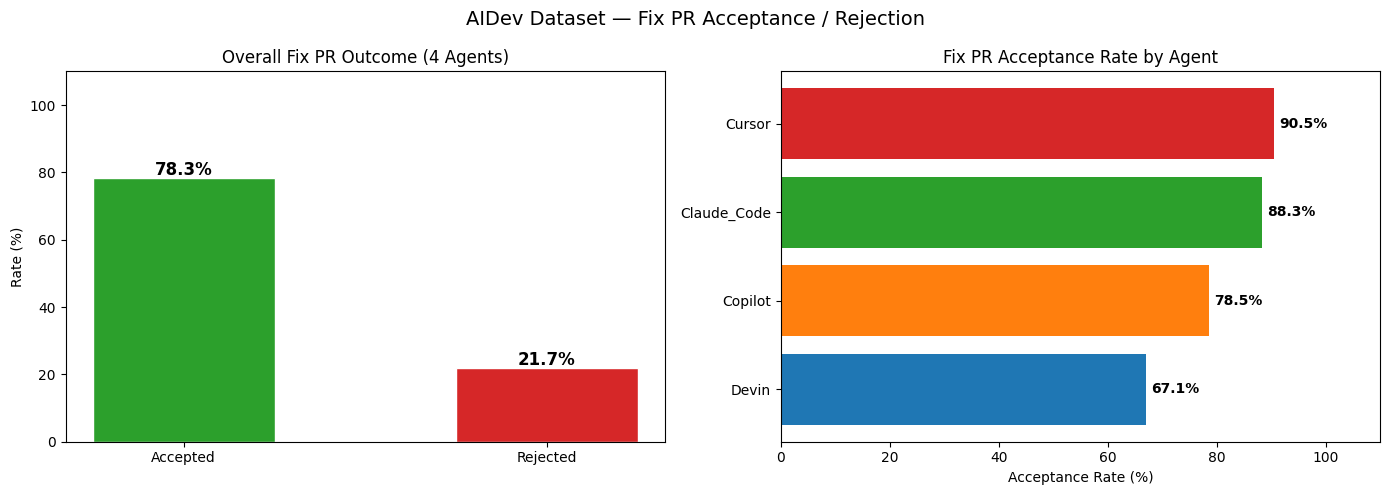


  -> Figure saved: results\aidev_report_figures\acceptance_rejection_rate.png


In [11]:
# ── Acceptance & rejection rate bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall acceptance vs rejection
bars = axes[0].bar(["Accepted", "Rejected"], [total_rate, rejection_rate],
                   color=["#2ca02c", "#d62728"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [total_rate, rejection_rate]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Overall Fix PR Outcome (4 Agents)")
axes[0].set_ylim(0, 110)

# Right: per-agent acceptance rate
agents_sorted = agent_stats_df.sort_values("%Acceptance", ascending=True)
colors = sns.color_palette("tab10", len(agents_sorted))
bars2 = axes[1].barh(agents_sorted["Agent"], agents_sorted["%Acceptance"], color=colors)
for bar, val in zip(bars2, agents_sorted["%Acceptance"]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Acceptance Rate (%)")
axes[1].set_title("Fix PR Acceptance Rate by Agent")
axes[1].set_xlim(0, 110)

fig.suptitle("AIDev Dataset — Fix PR Acceptance / Rejection", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "acceptance_rejection_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'acceptance_rejection_rate.png'}")

## Table: Acceptance and Merge Time Statistics

Replicates Table 2 from the paper.

In [12]:
section("Table: Acceptance and Merge Time Statistics of Fix PRs")


def compute_row(label, df):
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}h"]


rows = [compute_row("All 4 Agents", fix_prs)]
for agent_name in sorted(fix_prs["agent"].unique()):
    rows.append(compute_row(f"  {agent_name}", fix_prs[fix_prs["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Acceptance and merge time statistics of fix PRs (AIDev dataset).\n")
display(summary_df)

# Export as text
out(summary_df.to_string(index=False))


  Table: Acceptance and Merge Time Statistics of Fix PRs
Acceptance and merge time statistics of fix PRs (AIDev dataset).



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,All 4 Agents,"18,659","5,186","23,845",78.3%,0.26h
1,Claude_Code,"1,076",142,"1,218",88.3%,0.19h
2,Copilot,"8,421","2,302","10,723",78.5%,0.50h
3,Cursor,"4,546",476,"5,022",90.5%,0.02h
4,Devin,"4,616","2,266","6,882",67.1%,0.19h


     Category #Accepted #Rejected #Total %Acceptance Median Time to Merge
 All 4 Agents    18,659     5,186 23,845       78.3%                0.26h
  Claude_Code     1,076       142  1,218       88.3%                0.19h
      Copilot     8,421     2,302 10,723       78.5%                0.50h
       Cursor     4,546       476  5,022       90.5%                0.02h
        Devin     4,616     2,266  6,882       67.1%                0.19h


## Time to Merge Distribution

In [13]:
section("Time to Merge")

merged_prs = fix_prs[fix_prs["merged_at"].notna()].copy()
merged_prs["created_dt"] = pd.to_datetime(merged_prs["created_at"], utc=True)
merged_prs["merged_dt"] = pd.to_datetime(merged_prs["merged_at"], utc=True)
merged_prs["hours_to_merge"] = (merged_prs["merged_dt"] - merged_prs["created_dt"]).dt.total_seconds() / 3600

out(f"Merged fix PRs: {len(merged_prs):,}")
out(f"Overall median time to merge: {merged_prs['hours_to_merge'].median():.2f} hours")

out("\nPer-agent median time to merge:")
for agent_name in sorted(merged_prs["agent"].unique()):
    grp = merged_prs[merged_prs["agent"] == agent_name]
    med = grp["hours_to_merge"].median()
    out(f"  {agent_name:20s}  {med:.2f} hours  (n={len(grp):,})")


  Time to Merge
Merged fix PRs: 18,659
Overall median time to merge: 0.26 hours

Per-agent median time to merge:
  Claude_Code           0.19 hours  (n=1,076)
  Copilot               0.50 hours  (n=8,421)
  Cursor                0.02 hours  (n=4,546)
  Devin                 0.19 hours  (n=4,616)


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_29820\2991530745.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ttm, labels=labels_ttm, patch_artist=True,


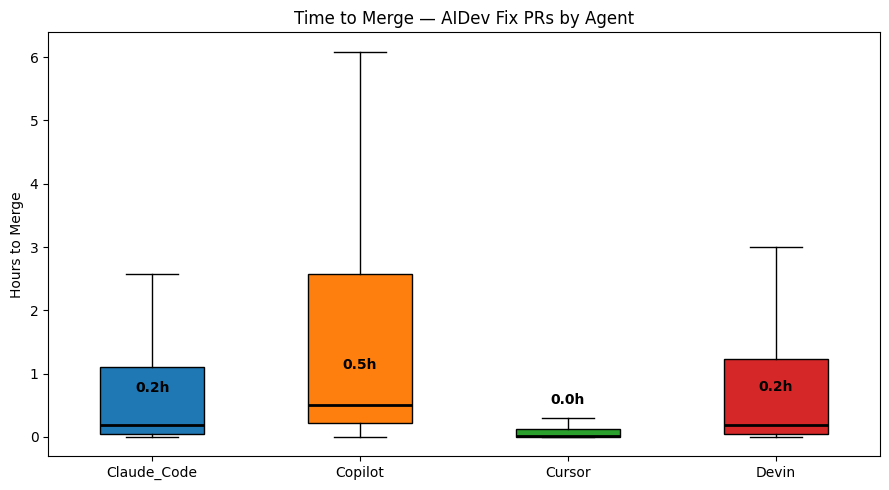

  -> Figure saved: results\aidev_report_figures\time_to_merge_by_agent.png


In [14]:
# Time-to-merge box plot per agent
agents_ordered = sorted(merged_prs["agent"].unique())
data_ttm = []
labels_ttm = []
for agent_name in agents_ordered:
    grp = merged_prs[merged_prs["agent"] == agent_name]
    # Clip at 95th percentile for visualization
    vals = grp["hours_to_merge"].clip(upper=grp["hours_to_merge"].quantile(0.95)).values
    data_ttm.append(vals)
    labels_ttm.append(agent_name)

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_ttm, labels=labels_ttm, patch_artist=True,
                widths=0.5, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
palette = sns.color_palette("tab10", len(agents_ordered))
for patch, c in zip(bp["boxes"], palette):
    patch.set_facecolor(c)
for i, vals in enumerate(data_ttm):
    med = np.median(vals)
    ax.text(i + 1, med * 1.15 + 0.5, f"{med:.1f}h", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Hours to Merge")
ax.set_title("Time to Merge — AIDev Fix PRs by Agent")
fig.tight_layout()
fig.savefig(FIG_DIR / "time_to_merge_by_agent.png", dpi=150)
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'time_to_merge_by_agent.png'}")

## Monthly Acceptance Rate Trends

In [15]:
section("Monthly Acceptance Rate")

fix_prs["created_month"] = pd.to_datetime(fix_prs["created_at"], utc=True).dt.to_period("M")

# Overall monthly
monthly_all = (
    fix_prs.groupby("created_month")["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
monthly_all["acceptance_rate"] = monthly_all["merged"] / monthly_all["total"] * 100

out("Monthly acceptance rate (all 4 agents):")
out(f"{'Month':<12} {'Merged':>8} {'Total':>8} {'Rate':>8}")
out("-" * 40)
for _, row in monthly_all.iterrows():
    out(f"{str(row['created_month']):<12} {int(row['merged']):>8,} {int(row['total']):>8,} {row['acceptance_rate']:>7.1f}%")


  Monthly Acceptance Rate
Monthly acceptance rate (all 4 agents):
Month          Merged    Total     Rate
----------------------------------------
2024-12            79      129    61.2%
2025-01           267      443    60.3%
2025-02           514      849    60.5%
2025-03           532    1,103    48.2%
2025-04           965    1,351    71.4%
2025-05         1,719    2,327    73.9%
2025-06         3,820    4,881    78.3%
2025-07        10,763   12,762    84.3%


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_29820\1245250167.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  fix_prs["created_month"] = pd.to_datetime(fix_prs["created_at"], utc=True).dt.to_period("M")


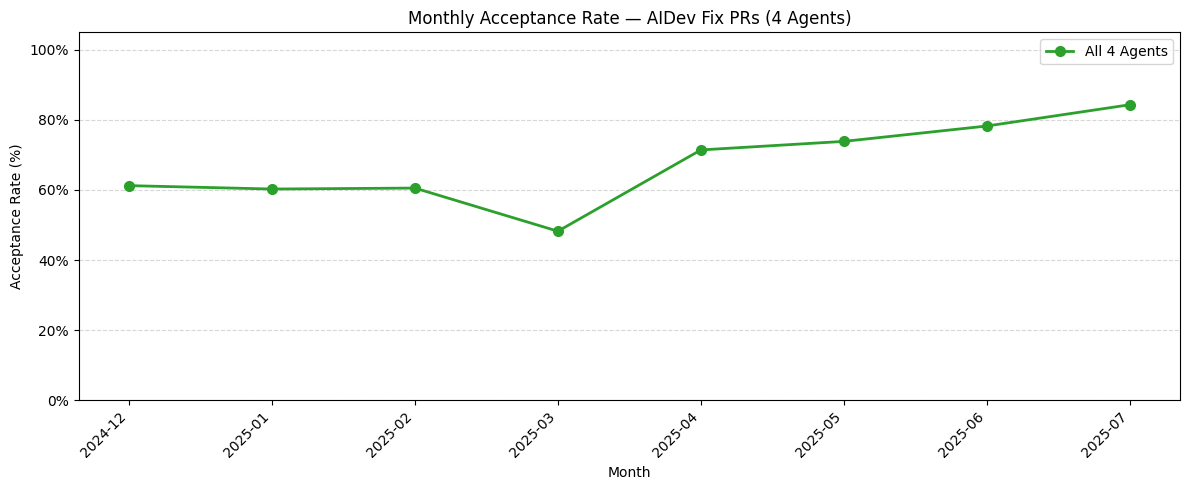


  -> Figure saved: results\aidev_report_figures\monthly_acceptance_rate.png


In [16]:
# Monthly acceptance rate — overall line chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_all["created_month"].astype(str), monthly_all["acceptance_rate"],
        "o-", color="#2ca02c", linewidth=2, markersize=7, label="All 4 Agents")
ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate — AIDev Fix PRs (4 Agents)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_acceptance_rate.png'}")

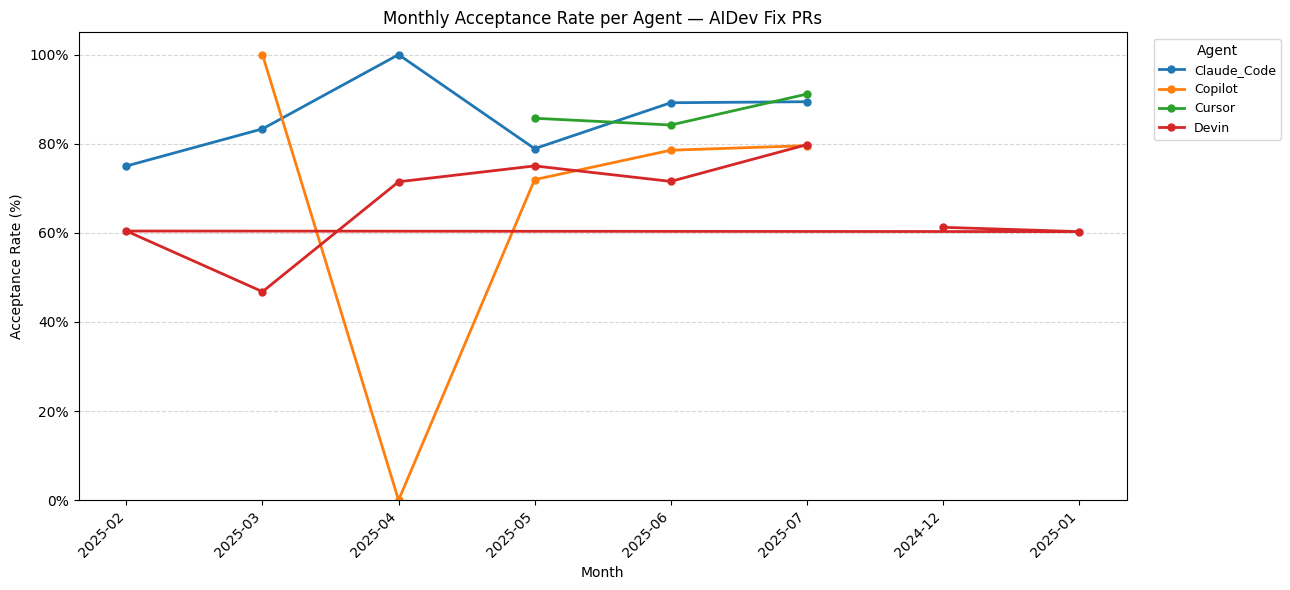

  -> Figure saved: results\aidev_report_figures\monthly_acceptance_rate_per_agent.png


In [17]:
# Monthly acceptance rate — per agent
per_agent_monthly = (
    fix_prs.groupby(["created_month", "agent"])["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
per_agent_monthly["acceptance_rate"] = per_agent_monthly["merged"] / per_agent_monthly["total"] * 100

agent_names = sorted(per_agent_monthly["agent"].unique())
palette = sns.color_palette("tab10", len(agent_names))

fig, ax = plt.subplots(figsize=(13, 6))
for agent_tool, color in zip(agent_names, palette):
    subset = per_agent_monthly[per_agent_monthly["agent"] == agent_tool].sort_values("created_month")
    ax.plot(
        subset["created_month"].astype(str),
        subset["acceptance_rate"],
        "o-", label=agent_tool, color=color, linewidth=2, markersize=5,
    )

ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate per Agent — AIDev Fix PRs")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_acceptance_rate_per_agent.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'monthly_acceptance_rate_per_agent.png'}")

## Monthly Volume

In [18]:
section("Monthly Fix PR Volume")

monthly_vol = fix_prs.groupby(["created_month", "agent"]).size().unstack(fill_value=0)
monthly_vol["Total"] = monthly_vol.sum(axis=1)

out(f"{'Month':<12}" + "".join(f"{a:>14}" for a in monthly_vol.columns))
out("-" * (12 + 14 * len(monthly_vol.columns)))
for period in monthly_vol.index:
    row = monthly_vol.loc[period]
    out(f"{str(period):<12}" + "".join(f"{int(row[c]):>14,}" for c in monthly_vol.columns))


  Monthly Fix PR Volume
Month          Claude_Code       Copilot        Cursor         Devin         Total
----------------------------------------------------------------------------------
2024-12                  0             0             0           129           129
2025-01                  0             0             0           443           443
2025-02                  8             0             0           841           849
2025-03                 42             1             0         1,060         1,103
2025-04                  6             3             0         1,342         1,351
2025-05                 90         1,005             7         1,225         2,327
2025-06                287         3,160           443           991         4,881
2025-07                785         6,554         4,572           851        12,762


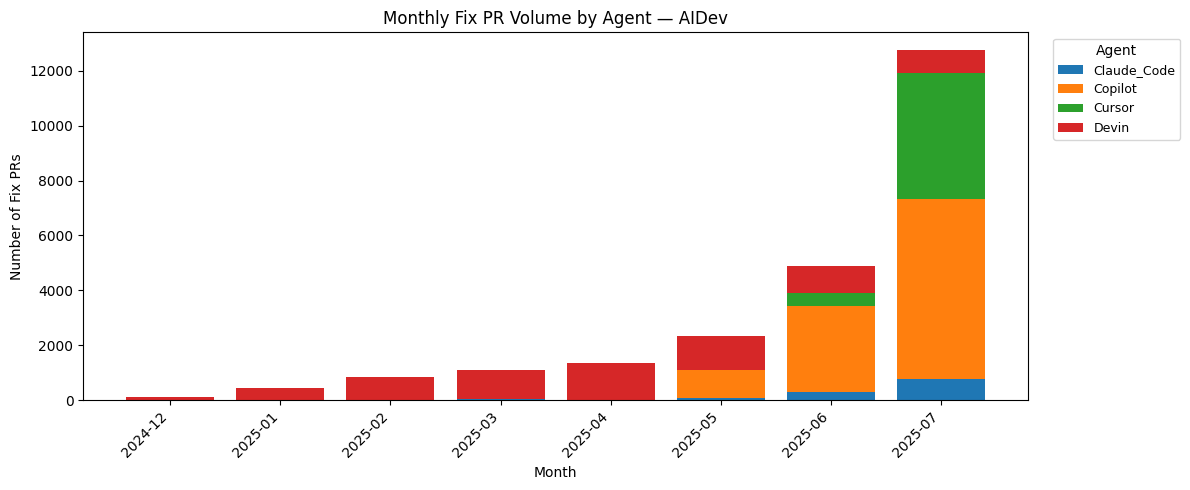


  -> Figure saved: results\aidev_report_figures\monthly_volume_by_agent.png


In [19]:
# Monthly volume stacked area
fig, ax = plt.subplots(figsize=(12, 5))
agent_cols = [c for c in monthly_vol.columns if c != "Total"]
palette_vol = sns.color_palette("tab10", len(agent_cols))
months_str = [str(p) for p in monthly_vol.index]

bottom = np.zeros(len(months_str))
for agent_name, color in zip(agent_cols, palette_vol):
    vals = monthly_vol[agent_name].values.astype(float)
    ax.bar(months_str, vals, bottom=bottom, label=agent_name, color=color)
    bottom += vals

ax.set_xlabel("Month")
ax.set_ylabel("Number of Fix PRs")
ax.set_title("Monthly Fix PR Volume by Agent — AIDev")
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_volume_by_agent.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_volume_by_agent.png'}")

## Top Repositories

In [20]:
section("Top 15 Repositories by Fix PRs")

top_repos = fix_prs["repo_name"].value_counts().head(15)
out(f"{'Repo':<55} {'Total':>7} {'Merged':>8} {'Rate':>8}")
out("-" * 80)
for repo, cnt in top_repos.items():
    repo_fix = fix_prs[fix_prs["repo_name"] == repo]
    m = repo_fix["is_merged"].sum()
    r = m / cnt * 100 if cnt else 0
    out(f"  {repo:53s} {cnt:>7,} {m:>8,} {r:>7.1f}%")


  Top 15 Repositories by Fix PRs
Repo                                                      Total   Merged     Rate
--------------------------------------------------------------------------------
  crewAIInc/crewAI                                          235       25    10.6%
  microsoft/vscode                                           76       30    39.5%
  liam-hq/liam                                               69       43    62.3%
  calcom/cal.com                                             58       20    34.5%
  novuhq/novu                                                49       45    91.8%
  airbytehq/airbyte                                          47       27    57.4%
  Cap-go/capgo                                               43        4     9.3%
  onlook-dev/onlook                                          38       11    28.9%
  mendableai/firecrawl                                       34       23    67.6%
  dotnet/aspire                                              34  

## Consistency Check Against Paper

The paper reports **3,225 fix PRs** across the 4 agents (repos >100 stars) with a **46.41% rejection rate**.
Let's verify our numbers are in the same ballpark.

In [21]:
section("Consistency Check")

out(f"Paper reports:")
out(f"  3,225 agent fix PRs, 1,497 rejected = 46.41% rejection")
out(f"")
out(f"Our computation from AIDev (same 4 agents, >100 star repos):")
out(f"  {len(fix_prs):,} closed agent fix PRs")
out(f"  {total_rejected:,} rejected = {rejection_rate:.2f}% rejection")
out(f"  {total_merged:,} accepted = {total_rate:.2f}% acceptance")
out(f"")
out(f"Note: Small differences are expected due to:")
out(f"  - AIDev dataset snapshot timing")
out(f"  - Minor differences in fix classification regex")
out(f"  - The paper may have applied additional filters")


  Consistency Check
Paper reports:
  3,225 agent fix PRs, 1,497 rejected = 46.41% rejection

Our computation from AIDev (same 4 agents, >100 star repos):
  23,845 closed agent fix PRs
  5,186 rejected = 21.75% rejection
  18,659 accepted = 78.25% acceptance

Note: Small differences are expected due to:
  - AIDev dataset snapshot timing
  - Minor differences in fix classification regex
  - The paper may have applied additional filters


## Including Codex (All 5 Agents)

In [22]:
section("All 5 Agents (including OpenAI Codex)")

print("Loading all agents including Codex ...")
all5_prs = pd.read_parquet(f"{AIDEV_BASE}/all_pull_request.parquet")
all5_prs["type"] = all5_prs["title"].apply(classify_title)
all5_fix = all5_prs[(all5_prs["type"] == "fix") & (all5_prs["state"] == "closed")].copy()
all5_fix["is_merged"] = all5_fix["merged_at"].notna()

out(f"Total closed fix PRs (all 5 agents): {len(all5_fix):,}")

out(f"\nPer-agent acceptance:")
for agent_name in sorted(all5_fix["agent"].unique()):
    grp = all5_fix[all5_fix["agent"] == agent_name]
    m, t, r = merge_rate(grp)
    rej = t - m
    out(f"  {agent_name:20s}  {m:>8,} / {t:>8,} merged = {r:.1f}%  (rejected: {rej:,} = {100 - r:.1f}%)")

m5, t5, r5 = merge_rate(all5_fix)
out(f"\n  {'TOTAL':20s}  {m5:>8,} / {t5:>8,} merged = {r5:.1f}%  (rejected: {t5 - m5:,} = {100 - r5:.1f}%)")


  All 5 Agents (including OpenAI Codex)
Loading all agents including Codex ...
Total closed fix PRs (all 5 agents): 207,192

Per-agent acceptance:
  Claude_Code              1,076 /    1,218 merged = 88.3%  (rejected: 142 = 11.7%)
  Copilot                  8,421 /   10,723 merged = 78.5%  (rejected: 2,302 = 21.5%)
  Cursor                   4,546 /    5,022 merged = 90.5%  (rejected: 476 = 9.5%)
  Devin                    4,616 /    6,882 merged = 67.1%  (rejected: 2,266 = 32.9%)
  OpenAI_Codex           173,399 /  183,347 merged = 94.6%  (rejected: 9,948 = 5.4%)

  TOTAL                  192,058 /  207,192 merged = 92.7%  (rejected: 15,134 = 7.3%)


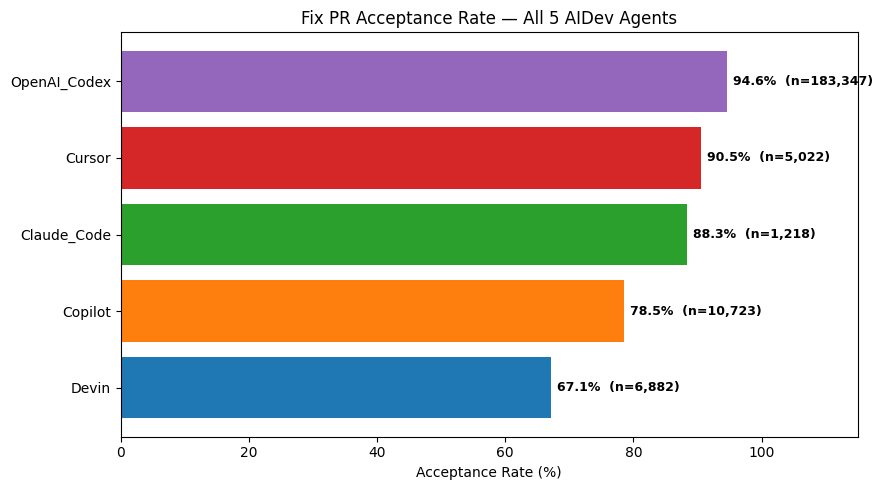


  -> Figure saved: results\aidev_report_figures\acceptance_rate_all_5_agents.png


In [23]:
# All 5 agents bar chart
all5_stats = []
for agent_name in sorted(all5_fix["agent"].unique()):
    grp = all5_fix[all5_fix["agent"] == agent_name]
    m, t, r = merge_rate(grp)
    all5_stats.append({"Agent": agent_name, "%Acceptance": r, "#Total": t})
all5_stats_df = pd.DataFrame(all5_stats).sort_values("%Acceptance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
palette5 = sns.color_palette("tab10", len(all5_stats_df))
bars = ax.barh(all5_stats_df["Agent"], all5_stats_df["%Acceptance"], color=palette5)
for bar, val, total in zip(bars, all5_stats_df["%Acceptance"], all5_stats_df["#Total"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%  (n={total:,})", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Acceptance Rate (%)")
ax.set_title("Fix PR Acceptance Rate — All 5 AIDev Agents")
ax.set_xlim(0, 115)
fig.tight_layout()
fig.savefig(FIG_DIR / "acceptance_rate_all_5_agents.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'acceptance_rate_all_5_agents.png'}")

## Save Report

In [24]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\aidev_report.txt
Figures saved to results\aidev_report_figures/
Done!
